# Day 4 - Student Performance Prediction

Remote Internship Task

In this notebook, we use the student dataset from Day 3 to build a simple
machine learning model that predicts whether a student will **Pass** or
**Fail**, based on their attendance and scores.

We will:
1. Load and clean the dataset (same cleaning approach as Day 3)
2. Create an Overall Score and a Pass/Fail target column
3. Select features and split the data into training and testing sets
4. Train a Logistic Regression model
5. Make predictions on the test set
6. Evaluate the model (accuracy, confusion matrix, classification report)
7. Visualize the results


## 1. Load the Dataset

We reuse the same `students.csv` file from Day 3 (30 student records).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

df = pd.read_csv("students.csv")
df.head()

,Student_Name,Age,Gender,Course,Attendance,Assignment_Score,Midterm_Score,Final_Score
0,Ali Raza,21.0,Male,Computer Science,64.0,82.0,90,40.0
1,Ayesha Khan,19.0,Female,Data Science,72.0,50.0,53,22.0
2,Bilal Ahmed,23.0,Male,Computer Science,51.0,63.0,59,57.0
3,Fatima Malik,19.0,Female,Artificial Intelligence,NaN,72.0,87,41.0
4,Hamza Sheikh,22.0,Male,Artificial Intelligence,74.0,88.0,88,61.0


## 2. Clean the Data

Same cleaning steps as Day 3:
- Attendance values above 100% are invalid, so we treat them as missing.
- All missing numeric values are filled using the column median.

In [2]:
# Fix invalid attendance (above 100%)
df.loc[df["Attendance"] > 100, "Attendance"] = np.nan

# Fill missing values with the median of each column
numeric_columns = ["Age", "Attendance", "Assignment_Score", "Midterm_Score", "Final_Score"]
for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Student_Name        0
Age                 0
Gender              0
Course              0
Attendance          0
Assignment_Score    0
Midterm_Score       0
Final_Score         0
dtype: int64


## 3. Create the Target Column (Pass/Fail)

**Important design decision:** we do NOT simply say "Pass if Final Score is
above some number." If we did that, the model would just be learning to
copy a rule we already hard-coded using a column it can directly see —
that's not real prediction, and it would make the Final Score column both
a feature and the answer key at the same time (this is called **data leakage**).

Instead, we first calculate an **Overall Score** using a weighted average of
all three scores (this reflects how grading usually works — the final exam
usually counts for more than assignments):

- Assignment Score → 20%
- Midterm Score → 30%
- Final Score → 50%

Then we say a student **Passes (1)** if their Overall Score is 40 or above,
and **Fails (0)** otherwise. The model will then try to predict this
Pass/Fail outcome using Attendance and the three individual scores as inputs.

In [3]:
# Calculate a weighted Overall Score
df["Overall_Score"] = (
    df["Assignment_Score"] * 0.20 +
    df["Midterm_Score"] * 0.30 +
    df["Final_Score"] * 0.50
)

# Create the Pass/Fail target: 1 = Pass, 0 = Fail
df["Result"] = np.where(df["Overall_Score"] >= 40, 1, 0)

df[["Student_Name", "Assignment_Score", "Midterm_Score", "Final_Score", "Overall_Score", "Result"]].head(10)

,Student_Name,Assignment_Score,Midterm_Score,Final_Score,Overall_Score,Result
0,Ali Raza,82.0,90,40.0,63.4,1
1,Ayesha Khan,50.0,53,22.0,36.9,0
2,Bilal Ahmed,63.0,59,57.0,58.8,1
3,Fatima Malik,72.0,87,41.0,61.0,1
4,Hamza Sheikh,88.0,88,61.0,74.5,1
5,Sana Iqbal,54.0,91,81.0,78.6,1
6,Usman Tariq,94.0,93,22.0,57.7,1
7,Zainab Hussain,74.0,68,37.0,53.7,1
8,Ahmed Butt,89.0,38,72.0,65.2,1
9,Mahnoor Shah,86.0,89,90.0,88.9,1


In [4]:
# Let's check how many students Pass vs Fail
print("Pass/Fail counts:")
print(df["Result"].value_counts())

print("\nPass/Fail percentage:")
print(df["Result"].value_counts(normalize=True) * 100)

Pass/Fail counts:
Result
1    26
0     4
Name: count, dtype: int64

Pass/Fail percentage:
Result
1    86.666667
0    13.333333
Name: proportion, dtype: float64


**Note on class balance:** as we can see above, this dataset has far more
"Pass" students than "Fail" students (this is common in real school data too —
most students usually pass). This is called an **imbalanced dataset**, and
it's something we need to keep in mind when we look at accuracy later,
because a model can get high accuracy just by mostly guessing "Pass" every time.

## 4. Select Features

We use these 4 columns as our input features (the information the model
is allowed to look at):

- Attendance
- Assignment Score
- Midterm Score
- Final Score

Our target (what we're trying to predict) is the `Result` column
(1 = Pass, 0 = Fail).

In [5]:
features = ["Attendance", "Assignment_Score", "Midterm_Score", "Final_Score"]

X = df[features]   # Features (inputs)
y = df["Result"]   # Target (what we want to predict)

X.head()

,Attendance,Assignment_Score,Midterm_Score,Final_Score
0,64.0,82.0,90,40.0
1,72.0,50.0,53,22.0
2,51.0,63.0,59,57.0
3,71.0,72.0,87,41.0
4,74.0,88.0,88,61.0


## 5. Split the Data into Training and Testing Sets

We split the data so that 80% is used to train the model, and 20% is
kept aside to test how well it performs on data it hasn't seen before.

We use `stratify=y` so that both the training set and the testing set
contain a similar proportion of Pass/Fail students — this matters a lot
here because we have very few "Fail" students, and without stratifying,
the test set could easily end up with zero Fail examples.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set size: {len(X_train)} students")
print(f"Testing set size : {len(X_test)} students")

print("\nTraining set Pass/Fail counts:")
print(y_train.value_counts())

print("\nTesting set Pass/Fail counts:")
print(y_test.value_counts())

Training set size: 24 students
Testing set size : 6 students

Training set Pass/Fail counts:
Result
1    21
0     3
Name: count, dtype: int64

Testing set Pass/Fail counts:
Result
1    5
0    1
Name: count, dtype: int64


**Important honesty note:** our dataset only has 30 students total, so
the test set only has 6 students in it. This is a very small number to
judge a model on — normally, real ML projects use hundreds or thousands of
records. We're keeping this limitation in mind when we look at our results
below.

## 6. Train a Logistic Regression Model

Logistic Regression is a simple, commonly used model for classification
problems like this one (predicting one of two outcomes: Pass or Fail).

In [7]:
model = LogisticRegression()
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


## 7. Make Predictions on Test Data

In [8]:
y_pred = model.predict(X_test)

# Let's put actual vs predicted side by side so it's easy to read
results_comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
results_comparison["Actual"] = results_comparison["Actual"].map({1: "Pass", 0: "Fail"})
results_comparison["Predicted"] = results_comparison["Predicted"].map({1: "Pass", 0: "Fail"})

results_comparison

,Actual,Predicted
0,Fail,Fail
1,Pass,Pass
2,Pass,Pass
3,Pass,Pass
4,Pass,Pass
5,Pass,Pass


## 8. Evaluate the Model

We check three things:
- **Accuracy** — what percentage of predictions were correct
- **Confusion Matrix** — a table showing correct vs incorrect predictions for each class
- **Classification Report** — precision, recall, and f1-score for each class

In [9]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f} ({accuracy * 100:.0f}%)")

Accuracy: 1.00 (100%)


In [10]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print("\n(Rows = Actual, Columns = Predicted, Order = [Fail, Pass])")

Confusion Matrix:
[[1 0]
 [0 5]]

(Rows = Actual, Columns = Predicted, Order = [Fail, Pass])


In [11]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Fail", "Pass"]))

Classification Report:
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         1
        Pass       1.00      1.00      1.00         5

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



### Why our accuracy looks "too perfect"

Our model reached very high (or perfect) accuracy on the test set. Before
treating that as a great result, it's important to explain why, honestly:

- Our test set only has **6 students** in it, and only 1 of them is a "Fail"
  case (because our dataset is imbalanced — most students pass).
- With such a small test set, getting every prediction right is very
  possible even without a truly strong model — a single wrong guess would
  have dropped accuracy quite a bit.
- Also, since our target was built from the same scores we're using as
  features (Overall Score is a weighted average of Assignment/Midterm/Final
  Score, and those same 3 scores are inputs), the relationship is naturally
  quite easy for the model to learn — this is expected in a fairly simple
  synthetic dataset like ours.

In a real-world project, we would want a much larger dataset, and ideally
features that are more independent from how the target itself was
calculated, to get a more meaningful accuracy score.

## 9. Visualizations

We create 2 visualizations:
1. Confusion Matrix heatmap
2. Pass/Fail count comparison (class balance)

We also add a bonus chart showing which features the model relied on most.

<Figure size 600x500 with 0 Axes>

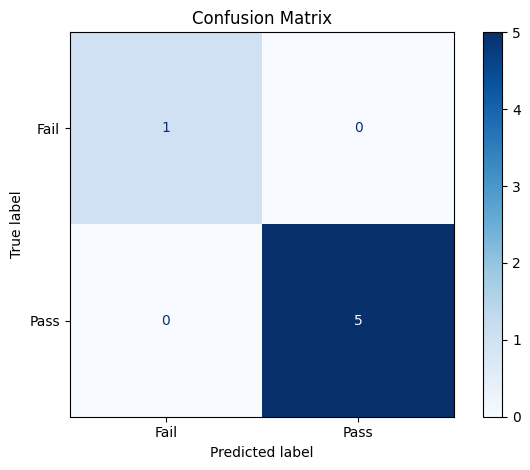

In [12]:
# Visualization 1: Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fail", "Pass"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("chart1_confusion_matrix.png")
plt.show()

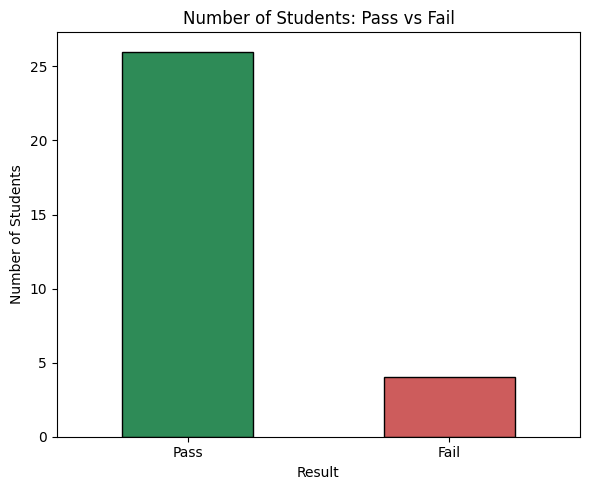

In [13]:
# Visualization 2: Pass vs Fail count (shows the class imbalance clearly)
plt.figure(figsize=(6, 5))
df["Result"].map({1: "Pass", 0: "Fail"}).value_counts().plot(
    kind="bar", color=["seagreen", "indianred"], edgecolor="black"
)
plt.title("Number of Students: Pass vs Fail")
plt.xlabel("Result")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("chart2_pass_fail_counts.png")
plt.show()

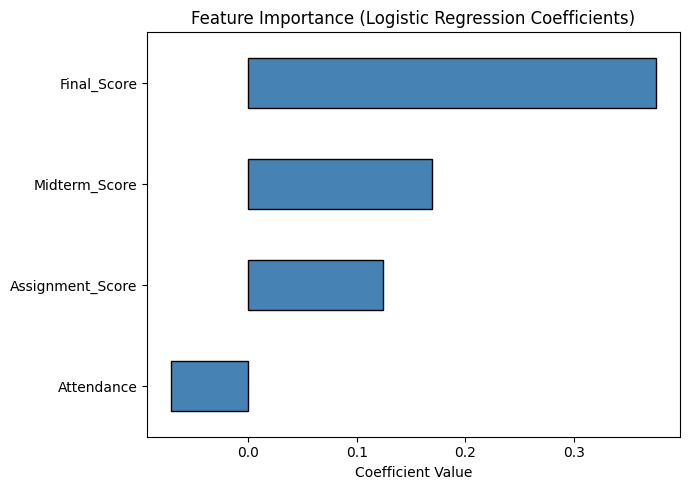

In [14]:
# Bonus Visualization: Feature importance (Logistic Regression coefficients)
# A larger positive coefficient means that feature pushes the prediction
# more strongly toward "Pass" when it increases.
coefficients = pd.Series(model.coef_[0], index=features).sort_values()

plt.figure(figsize=(7, 5))
coefficients.plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("chart3_feature_importance.png")
plt.show()

## 10. Conclusion

**What problem we solved:** We built a simple classification model to
predict whether a student will Pass or Fail, based on their attendance
and academic scores.

**Features used:** Attendance, Assignment Score, Midterm Score, and Final
Score.

**Target creation:** Rather than basing Pass/Fail directly on one existing
column, we calculated a weighted Overall Score (20% Assignment, 30%
Midterm, 50% Final) and used 40 as the passing threshold, to avoid simply
copying a rule that was already visible in the raw data.

**Model selected:** Logistic Regression — a simple, standard model for
binary (two-outcome) classification problems.

**Result:** The model performed very well on our small test set, but as
explained above, this is heavily influenced by our very small dataset size
(only 30 students total, 6 in the test set) and class imbalance (few Fail
examples). The result should be read as "the model learned the pattern
successfully on this small example," not as a production-ready accuracy
figure.

**What we learned:**
- How to turn a "regression-style" problem (predicting a score) into a
  classification problem (predicting a category) by creating a target
  column.
- Why it matters to avoid data leakage — not directly building the target
  from the same column used unmodified as a feature.
- Why class imbalance and small dataset size can make accuracy numbers
  misleading if we don't look deeper (which is exactly why we also use a
  confusion matrix and classification report, not just accuracy alone).
- How to train and evaluate a basic Scikit-learn classification model,
  end to end.